In [1]:
%load_ext autoreload

In [151]:
%autoreload 2
from mabot.browser.browser import AgentBrowser
from mabot.browser.markup import (
    ClusterWebElements,
    WebElementSelectorByCursorCss,
)

In [169]:
selector = WebElementSelectorByCursorCss(
    style=["pointer", "text"], is_displayed=True
)
browser = AgentBrowser(
    "https://google.com/", selector=selector, font_size=50, label_margin=5
)

2025-01-07 19:58:25.242 | INFO     | mabot.browser.browser:__init__:36 - Initialize driver
python(78745) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(78783) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
2025-01-07 19:58:27.097 | INFO     | mabot.browser.browser:__init__:39 - Get URL: 'https://google.com/'
2025-01-07 19:58:33.704 | INFO     | mabot.browser.markup:__init__:128 - Number of elements: 18
2025-01-07 19:58:33.707 | INFO     | mabot.browser.browser:__init__:44 - Initialize browser. Start from 'https://google.com/'


In [212]:
browser.click(13)

In [213]:
cluster = ClusterWebElements(min_samples=2, eps=0.2, algorithm="kd_tree")
img = browser.markup.markup_screenshot_cluster(cluster)

python(95236) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


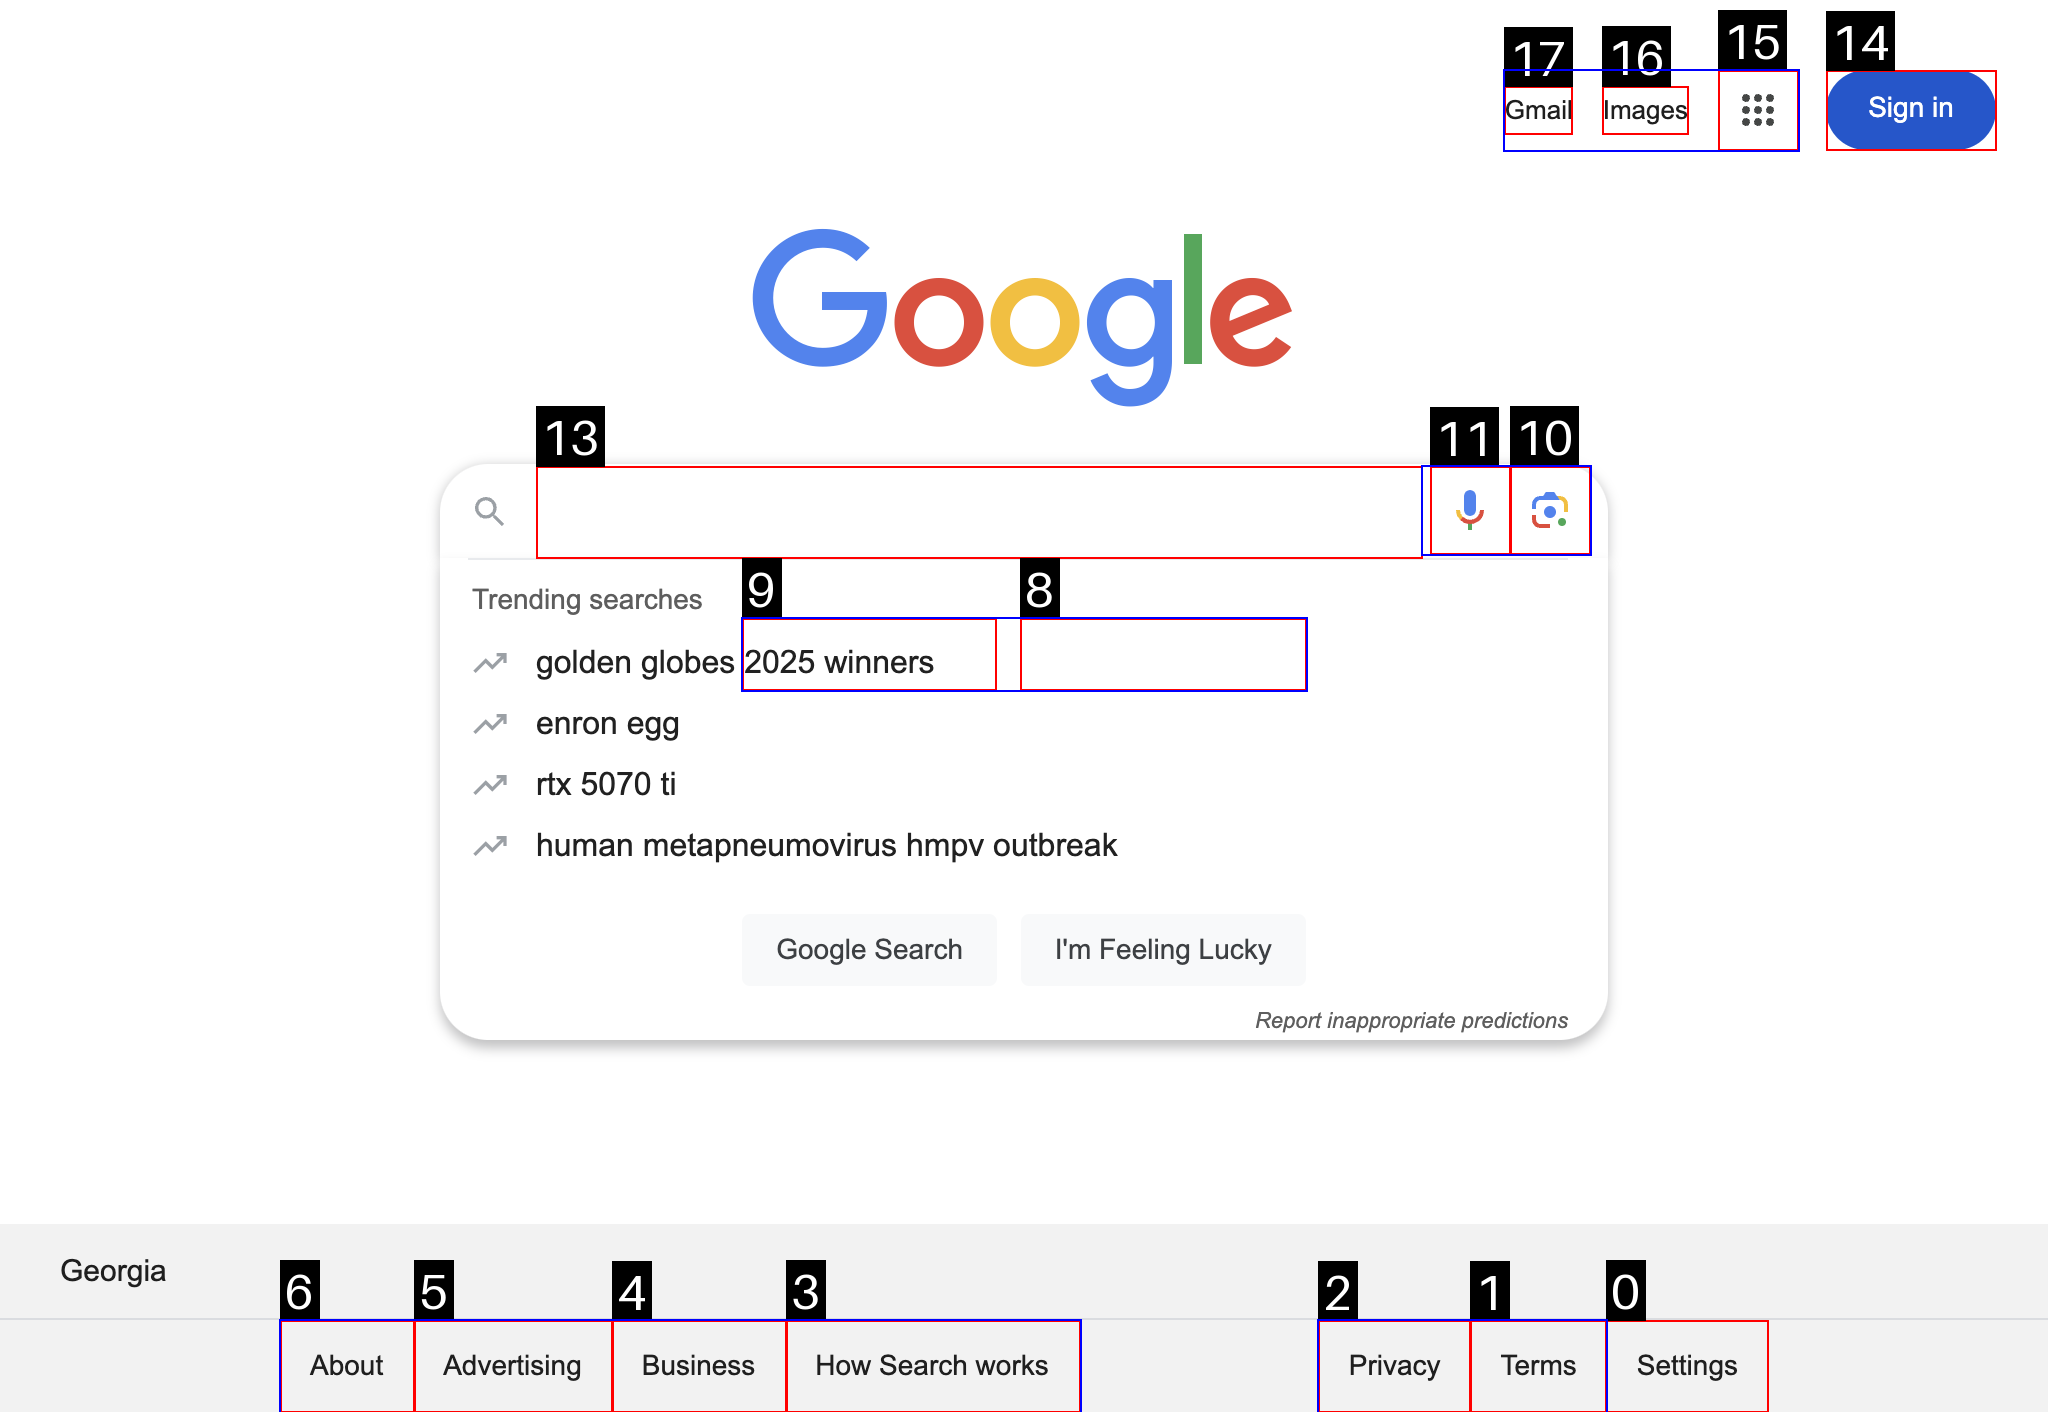

In [214]:
img

```python
cluster._cluster.labels_
```


In [173]:
img.save("img.png")

```python
import ollama
```


```python
mes = ollama.generate(
    model="llama3.2-vision",
    prompt="""
    You analyse web page screenshot.
    Interactive visible elements have its own red bounding box and numeric index in the black box on the top left corner.
    List all elements with numeric index on the screenshot.
    Strictly follow instructions below.

    **Answer format**
    - *Element numeric index*: *Element description*

    **Instructions**
    Element index should be exactly a number in the corresponding black box.
    Strictly analyse elements only visible on the screenshot.
    List elements only with index in black box on the top-left corner of the corresponding element.
    """,
    images=["/Users/arseniy/Documents/Workspace/mabot/img.png"],
)
```


**Answer:**

1. Terms
2. Privacy
3. How Search works
4. Business
5. Advertising
6. About
7. Google Search
8. I'm Feeling Lucky
9. Google Search
10. Microphone icon
11. Settings
12. Gmail
13. Search bar
14. Sign in button
15. Image icon
16. Images link
17. Gmail link


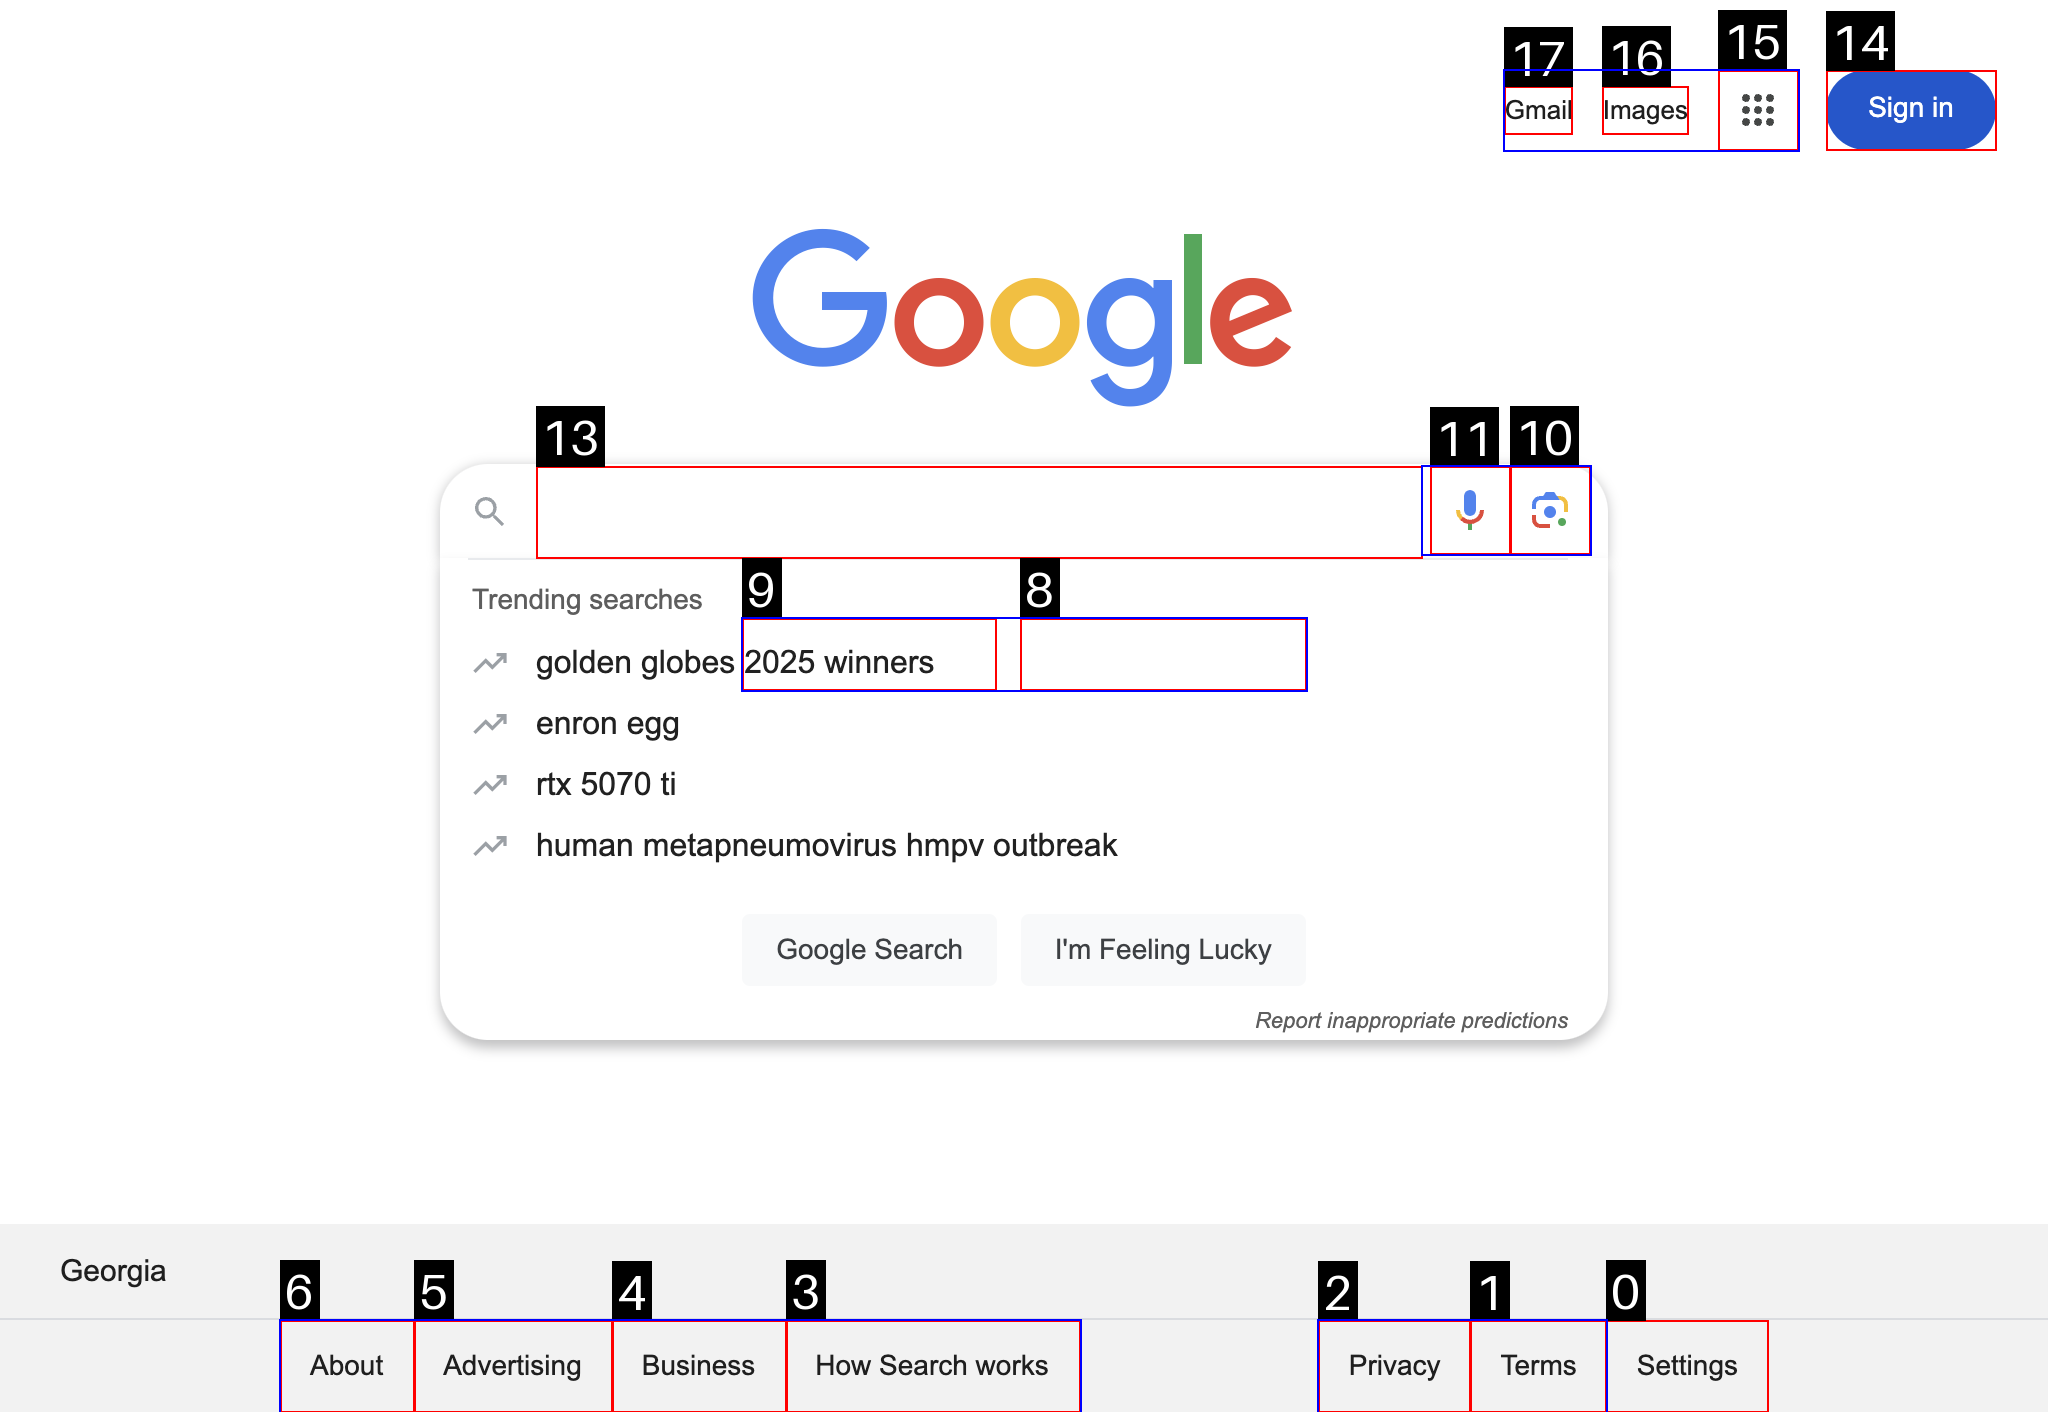

In [215]:
img

```python
mes = ollama.generate(
    model="llama3.2-vision",
    prompt="""
    You are a web browser user.

    You start from a web site and have a **User Prompt** to resolve with the turn-based game.
    At every turn you observe current browser view and you have to choose an action from **Actions** to interact with the browser.
    Browser view is a screenshot with interactive elements having its own red bounding box and the interactive element numeric index in the black box on the top left corner.
    Actions that have *element index* parameter are applied to the corresponding interactive element.
    When choosing actions strictly follow instructions below.

    **Actions**
    - Click[*element index*] - click on the element
    - TypeText[*element index*, *text*] - Type *text* into the element with number *element index*
    - ScrollUp - scroll up half of the view
    - ScrollDown - scroll down half of the view
    - GoBack - Go back on the previous page
    - Respond with the answer for the **User Prompt**

    You have to respond one of the items which have STRICTLY following format:
    - Click[*element index*]
    - ScrollUp
    - ScrollDown
    - TypeText[*element index*, *text*]
    - GoBack
    - ANSWER: <your answer for the **User Prompt**>

    **Instructions**
    - Choose only one action at every turn
    - *element index* is the number in black box on the top left corner of the element.
    - Select strategically to minimize time wasted.
    - DO NOT use elements which are not on the screenshot.
    - Do not repeat failed actions
    - Check that you do not stuck

    **User Prompt**
    Find how to import python modules on stackoverflow website.

    **Action History**
    - Click[13] - SUCCESS

    **Your response**
    *Thought*: {{briefly summarize the info that will help to solve the **User Prompt**}}
    *Explain*: {{Explain choice of action and *element index*}}
    *Action*: {{One Action format you choose}}
    """,
    images=["/Users/arseniy/Documents/Workspace/mabot/img.png"],
)
```
